In [2]:
import glob
import os

files = glob.glob('data/**/*.csv', recursive=True)
print(f"Found {len(files)} files")

Found 106 files


In [3]:
import pandas as pd

dfs = []
for f in files:
    df = pd.read_csv(f)
    df['match'] = os.path.basename(os.path.dirname(f))
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(data.shape)

(36572, 53)


In [5]:
data['rally_id'] = data['match'] + '_' + data['rally'].astype(str)

print(f"Unique rallies: {data['rally_id'].nunique()}")
print(f"Unique matches: {data['match'].nunique()}")

Unique rallies: 1696
Unique matches: 45


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# aggregate per rally
features = data.groupby('rally_id').agg(
    rally_length=('ball_round', 'max'),
    prop_aroundhead=('aroundhead', 'mean'),
    prop_backhand=('backhand', 'mean'),
    prop_above_net=('hit_height', 'mean'),
    avg_landing_x=('landing_x', 'mean'),
    avg_landing_y=('landing_y', 'mean'),
    std_landing_x=('landing_x', 'std'),
    std_landing_y=('landing_y', 'std'),
    avg_player_x=('player_location_x', 'mean'),
    avg_player_y=('player_location_y', 'mean'),
).dropna()

print(f"Rally vectors shape: {features.shape}")

# scale and cluster
scaled = StandardScaler().fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42).fit(scaled)
features['cluster'] = kmeans.labels_

score = silhouette_score(scaled, kmeans.labels_)
print(f"Silhouette score: {score:.3f}")
print(features['cluster'].value_counts())

Rally vectors shape: (1203, 10)
Silhouette score: 0.154
cluster
0    429
3    348
1    252
2    174
Name: count, dtype: int64


In [9]:
pip install umap-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\ryant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ryant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


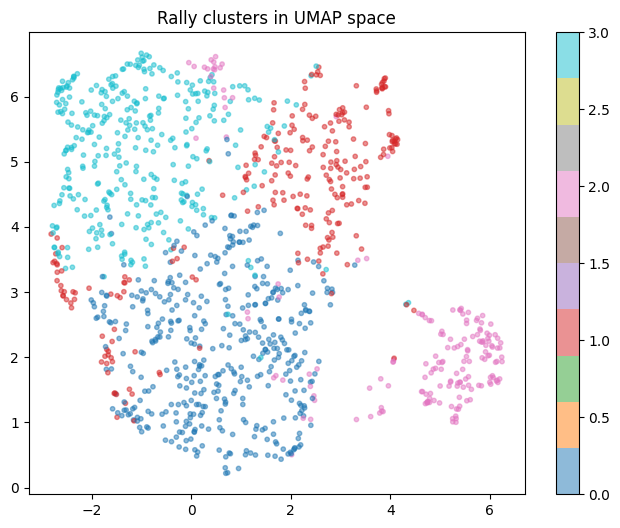

In [10]:
import umap
import matplotlib.pyplot as plt

embedding = umap.UMAP(random_state=42).fit_transform(scaled)

plt.figure(figsize=(8,6))
plt.scatter(embedding[:,0], embedding[:,1], 
            c=kmeans.labels_, cmap='tab10', alpha=0.5, s=10)
plt.title('Rally clusters in UMAP space')
plt.colorbar()
plt.show()

In [11]:
print(features.groupby('cluster')[['rally_length', 'prop_above_net', 'prop_backhand', 'avg_landing_y']].mean().round(2))

         rally_length  prop_above_net  prop_backhand  avg_landing_y
cluster                                                            
0               12.71            1.64            1.0         457.54
1               27.12            1.57            1.0         456.54
2               15.84            1.69            1.0         417.16
3               12.35            1.66            1.0         457.51


(1203, 29)
Silhouette score with shot types: 0.050


c:\Users\ryant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


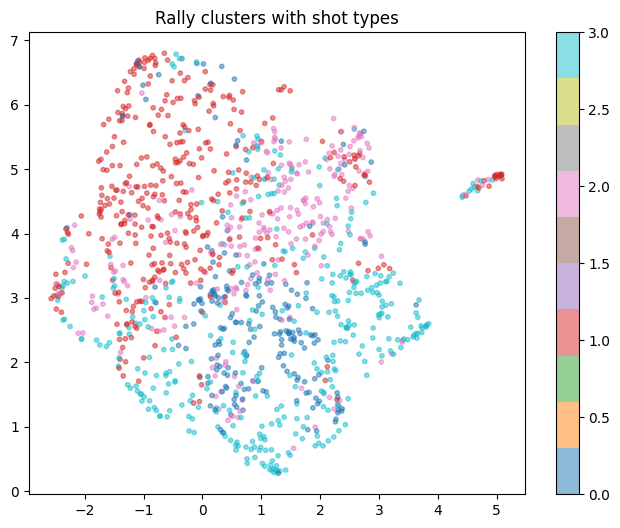

In [12]:
# get shot type distribution per rally
shot_dummies = pd.get_dummies(data['type'], prefix='shot')
data_with_shots = pd.concat([data[['rally_id']], shot_dummies], axis=1)
shot_features = data_with_shots.groupby('rally_id').mean()

# combine with existing features
features_full = features.drop('cluster', axis=1).join(shot_features)
features_full = features_full.dropna()

print(features_full.shape)

# recluster
scaled_full = StandardScaler().fit_transform(features_full)
kmeans_full = KMeans(n_clusters=4, random_state=42).fit(scaled_full)
score_full = silhouette_score(scaled_full, kmeans_full.labels_)
print(f"Silhouette score with shot types: {score_full:.3f}")

# replot
embedding_full = umap.UMAP(random_state=42).fit_transform(scaled_full)
plt.figure(figsize=(8,6))
plt.scatter(embedding_full[:,0], embedding_full[:,1],
            c=kmeans_full.labels_, cmap='tab10', alpha=0.5, s=10)
plt.title('Rally clusters with shot types')
plt.colorbar()
plt.show()

In [14]:
print(data['type'].value_counts())

type
放小球      6290
挑球       5331
擋小球      3620
推球       2925
長球       2922
殺球       2586
切球       2144
發短球      2051
點扣       1648
未知球種     1407
勾球       1371
過度切球     1356
平球        700
撲球        512
後場抽平球     473
防守回抽      406
發長球       373
防守回挑      301
小平球        68
Name: count, dtype: int64


In [15]:
shot_map = {
    '放小球': 'net', '擋小球': 'net', '推球': 'net', '勾球': 'net',
    '殺球': 'attacking', '點扣': 'attacking', '平球': 'attacking', 
    '撲球': 'attacking', '後場抽平球': 'attacking', '小平球': 'attacking',
    '挑球': 'defensive', '長球': 'defensive', '防守回抽': 'defensive', '防守回挑': 'defensive',
    '切球': 'neutral', '過度切球': 'neutral', '未知球種': 'neutral',
    '發短球': 'serve', '發長球': 'serve'
}

data['shot_category'] = data['type'].map(shot_map)
print(data['shot_category'].value_counts())

shot_category
net          14206
defensive     8960
attacking     5987
neutral       4907
serve         2424
Name: count, dtype: int64


Silhouette score with bucketed shot types: 0.108


c:\Users\ryant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


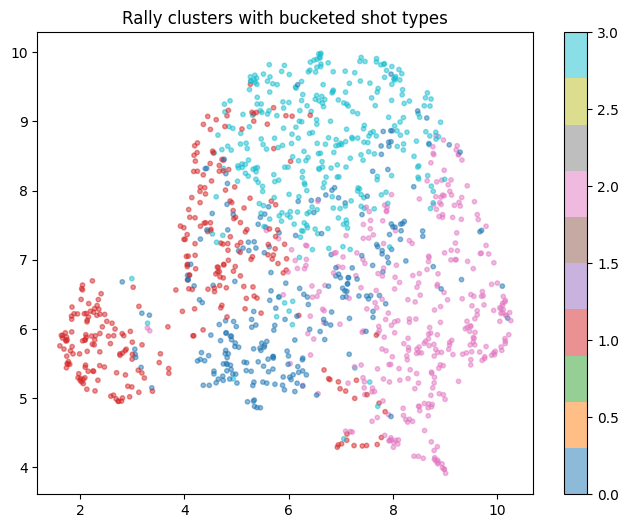

In [16]:
shot_dummies2 = pd.get_dummies(data['shot_category'], prefix='shot')
data_with_shots2 = pd.concat([data[['rally_id']], shot_dummies2], axis=1)
shot_features2 = data_with_shots2.groupby('rally_id').mean()

features_full2 = features.drop('cluster', axis=1).join(shot_features2)
features_full2 = features_full2.dropna()

scaled_full2 = StandardScaler().fit_transform(features_full2)
kmeans_full2 = KMeans(n_clusters=4, random_state=42).fit(scaled_full2)
score_full2 = silhouette_score(scaled_full2, kmeans_full2.labels_)
print(f"Silhouette score with bucketed shot types: {score_full2:.3f}")

embedding_full2 = umap.UMAP(random_state=42).fit_transform(scaled_full2)
plt.figure(figsize=(8,6))
plt.scatter(embedding_full2[:,0], embedding_full2[:,1],
            c=kmeans_full2.labels_, cmap='tab10', alpha=0.5, s=10)
plt.title('Rally clusters with bucketed shot types')
plt.colorbar()
plt.show()

In [18]:
features_combined = features.drop('cluster', axis=1).join(shot_features2)
features_combined = features_combined.dropna()

scaled_combined = StandardScaler().fit_transform(features_combined)
kmeans_combined = KMeans(n_clusters=4, random_state=42).fit(scaled_combined)
score_combined = silhouette_score(scaled_combined, kmeans_combined.labels_)
print(f"Combined silhouette score: {score_combined:.3f}")

# also check cluster means
features_combined['cluster'] = kmeans_combined.labels_
print(features_combined.groupby('cluster')[['rally_length', 'prop_above_net', 'shot_attacking', 'shot_defensive', 'shot_net', 'shot_serve']].mean().round(2))

Combined silhouette score: 0.108
         rally_length  prop_above_net  shot_attacking  shot_defensive  \
cluster                                                                 
0               11.91            1.61            0.22            0.25   
1               16.69            1.69            0.16            0.20   
2               20.35            1.57            0.13            0.34   
3               14.19            1.68            0.17            0.19   

         shot_net  shot_serve  
cluster                        
0            0.31        0.10  
1            0.45        0.08  
2            0.30        0.04  
3            0.43        0.09  


In [19]:
features_combined['cluster'] = kmeans_combined.labels_
print(features_combined.groupby('cluster')[['rally_length', 'prop_above_net', 'shot_attacking', 'shot_defensive', 'shot_net', 'shot_serve']].mean().round(2))

         rally_length  prop_above_net  shot_attacking  shot_defensive  \
cluster                                                                 
0               11.91            1.61            0.22            0.25   
1               16.69            1.69            0.16            0.20   
2               20.35            1.57            0.13            0.34   
3               14.19            1.68            0.17            0.19   

         shot_net  shot_serve  
cluster                        
0            0.31        0.10  
1            0.45        0.08  
2            0.30        0.04  
3            0.43        0.09  


In [20]:
kmeans3 = KMeans(n_clusters=3, random_state=42).fit(scaled_combined)
score3 = silhouette_score(scaled_combined, kmeans3.labels_)
print(f"Silhouette score k=3: {score3:.3f}")

Silhouette score k=3: 0.113


In [21]:
scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42).fit(scaled_combined)
    scores[k] = silhouette_score(scaled_combined, km.labels_)

for k, s in scores.items():
    print(f"k={k}: {s:.3f}")

k=2: 0.127
k=3: 0.113
k=4: 0.108
k=5: 0.117
k=6: 0.106
k=7: 0.098


In [22]:
features_no_length = features_combined.drop(['cluster', 'rally_length'], axis=1)

scaled_no_length = StandardScaler().fit_transform(features_no_length)

scores_no_length = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42).fit(scaled_no_length)
    scores_no_length[k] = silhouette_score(scaled_no_length, km.labels_)

for k, s in scores_no_length.items():
    print(f"k={k}: {s:.3f}")

k=2: 0.135
k=3: 0.123
k=4: 0.124
k=5: 0.119
k=6: 0.113
k=7: 0.108


In [23]:
km_best = KMeans(n_clusters=4, random_state=42).fit(scaled_no_length)
features_no_length['cluster'] = km_best.labels_
print(features_no_length.groupby('cluster')[['prop_above_net', 'shot_attacking', 'shot_defensive', 'shot_net', 'shot_serve', 'avg_landing_y', 'std_landing_x']].mean().round(2))

         prop_above_net  shot_attacking  shot_defensive  shot_net  shot_serve  \
cluster                                                                         
0                  1.61            0.24            0.22      0.34        0.11   
1                  1.69            0.14            0.19      0.45        0.07   
2                  1.68            0.19            0.22      0.42        0.10   
3                  1.57            0.14            0.35      0.28        0.05   

         avg_landing_y  std_landing_x  
cluster                                
0               461.14         149.39  
1               453.79         157.32  
2               420.01         134.08  
3               458.11         165.42  


In [24]:
features_no_length.groupby('cluster').mean().round(2).T

cluster,0,1,2,3
prop_aroundhead,1.00,1.00,1.00,1.00
prop_backhand,1.00,1.00,1.00,1.00
prop_above_net,1.61,1.69,1.68,1.57
avg_landing_x,651.58,633.35,608.49,631.58
avg_landing_y,461.14,453.79,420.01,458.11
std_landing_x,149.39,157.32,134.08,165.42
std_landing_y,107.64,97.66,109.88,113.69
avg_player_x,647.01,634.56,621.78,635.25
avg_player_y,462.00,456.20,422.06,460.78
shot_attacking,0.24,0.14,0.19,0.14


In [25]:
dead_features = ['prop_aroundhead', 'prop_backhand', 'prop_above_net']
features_clean = features_no_length.drop(dead_features + ['cluster'], axis=1)

scaled_clean = StandardScaler().fit_transform(features_clean)

scores_clean = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42).fit(scaled_clean)
    scores_clean[k] = silhouette_score(scaled_clean, km.labels_)

for k, s in scores_clean.items():
    print(f"k={k}: {s:.3f}")

k=2: 0.134
k=3: 0.128
k=4: 0.126
k=5: 0.120
k=6: 0.109
k=7: 0.108
